<div style="margin-bottom: 32px;">
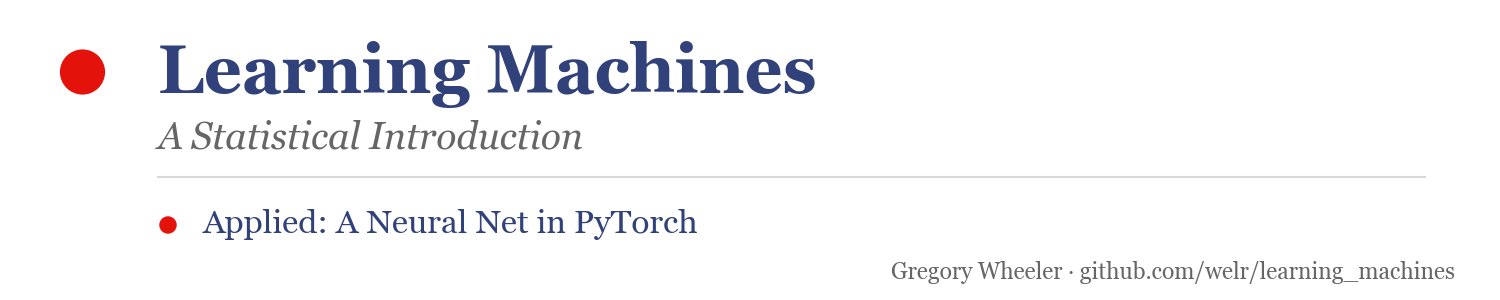
</div>


# Latent Semantic Analysis — Topics as Singular Directions

The book's Section 13.1 factors a three-document corpus by hand and shows that truncating the SVD turns word counts into topics. This notebook first verifies that example, then builds a corpus just large enough to show the effect the tiny one cannot: two terms that **never appear in the same document** end up almost identical in the latent space, and a query using one of them retrieves documents that only contain the other. Companion to Chapter 13.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Colab: fetch the plot-style helper if it isn't beside this notebook
import os as _os, urllib.request as _ur
if not _os.path.exists("mlone_theme.py"):
    _BASE = "https://raw.githubusercontent.com/welr/learning_machines/main/"
    for _f in ("mlone_theme.py", "mlone_style.mplstyle"):
        _ur.urlretrieve(_BASE + _f, _f)
import mlone_theme as mt

plt.style.use("mlone_style.mplstyle")
mt.set_notebook_mode()                      # green family for notebooks

## The book's corpus, verified

Three documents over the vocabulary (*loan*, *interest*, *flour*, *oven*): two loan-office documents and a recipe. The SVD should return singular values $3$, $\sqrt{2}$, $1$, and the rank-two reconstruction should make the two loan-office rows identical.

In [2]:
vocab_small = ["loan", "interest", "flour", "oven"]
X_small = np.array([[2, 1, 0, 0],
                    [1, 2, 0, 0],
                    [0, 0, 1, 1]], dtype=float)

U, d, Vt = np.linalg.svd(X_small, full_matrices=False)
print("singular values:", np.round(d, 4))          # 3, sqrt(2) = 1.4142, 1

k = 2
X_hat = U[:, :k] @ np.diag(d[:k]) @ Vt[:k, :]      # rank-2 reconstruction
print("rank-2 reconstruction:")
print(np.round(X_hat, 4))

singular values: [3.     1.4142 1.    ]
rank-2 reconstruction:
[[1.5 1.5 0.  0. ]
 [1.5 1.5 0.  0. ]
 [0.  0.  1.  1. ]]


The reconstruction matches the book: both loan-office rows become $(1.5, 1.5, 0, 0)$. The discarded third direction is *loan minus interest* — the word-choice difference between the two finance documents, treated as noise.

## A corpus where synonymy can show

In the tiny corpus, *loan* and *interest* co-occur, so their similarity is visible in the raw counts. The interesting case is a pair of terms that never share a document. We construct one: thirty-six documents on two topics, where every finance document says *bank* and *interest* but uses **either** *loan* **or** *credit*, never both — and every cooking document says *flour* and *bake* but uses either *oven* or *stove*. The synonym pairs are linked only through the company they keep. (The two topics get different document counts and hub weights on purpose: identical blocks would tie the two leading singular values, and a tie leaves the individual axes undetermined — the degeneracy flagged in Theorem 13.1.)

In [3]:
vocab = ["loan", "credit", "bank", "interest", "rate", "payment",
         "oven", "stove", "flour", "bake", "dough", "recipe"]
col = {term: j for j, term in enumerate(vocab)}

def finance_doc(i):
    counts = {}
    synonym = "loan" if i % 2 == 0 else "credit"   # never both
    counts[synonym] = 1 + (i % 3 == 0)             # 2 or 1 occurrences
    counts["bank"] = 2 + (i % 5 == 0)              # hub words: in every doc
    counts["interest"] = 2
    if i % 3 == 1:                                 # occasional extras
        counts["rate"] = 1
    if i % 4 == 2:
        counts["payment"] = 1
    return counts

def cooking_doc(i):
    counts = {}
    synonym = "oven" if i % 2 == 0 else "stove"    # never both
    counts[synonym] = 1 + (i % 3 == 0)
    counts["flour"] = 2 + (i % 4 == 0)
    counts["bake"] = 2
    if i % 3 == 1:
        counts["dough"] = 1
    if i % 4 == 2:
        counts["recipe"] = 1
    return counts

docs = [finance_doc(i) for i in range(20)] + [cooking_doc(i) for i in range(16)]
topic = ["finance"] * 20 + ["cooking"] * 16

X = np.zeros((len(docs), len(vocab)))
for i, counts in enumerate(docs):
    for term, c in counts.items():
        X[i, col[term]] = c

print("document-term matrix:", X.shape)
print("loan and credit ever co-occur?",
      bool(np.any((X[:, col["loan"]] > 0) & (X[:, col["credit"]] > 0))))

document-term matrix: (36, 12)
loan and credit ever co-occur? False


## Factor and truncate

The singular values should show two dominant directions — one per topic — followed by a tail of within-topic variation.

In [4]:
U, d, Vt = np.linalg.svd(X, full_matrices=False)
print("singular values:", np.round(d, 2))

k = 2
for j in range(k):                  # canonical signs: topic loadings positive
    if Vt[j].sum() < 0:
        Vt[j] *= -1
        U[:, j] *= -1

doc_coords  = U[:, :k] * d[:k]      # documents in the latent plane (rows of U_k D_k)
term_coords = Vt[:k, :].T * d[:k]   # terms in the same plane      (rows of V_k D_k)

singular values: [14.16 12.82  4.67  4.27  2.32  2.03  1.79  1.58  1.31  0.99  0.96  0.32]


## The synonym effect

*Loan* and *credit* never co-occur, so as raw count columns they are exactly orthogonal: cosine zero. In the latent plane, both load on the finance direction, because both co-occur with *bank* and *interest*. Truncation has merged what the counts kept apart.

In [5]:
def cosine(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

pairs = [("loan", "credit"), ("oven", "stove"), ("loan", "oven")]
print(f"{'pair':>16}  {'raw cosine':>10}  {'latent cosine':>13}")
for s, t in pairs:
    raw    = cosine(X[:, col[s]], X[:, col[t]])
    latent = cosine(term_coords[col[s]], term_coords[col[t]])
    print(f"{s + ' / ' + t:>16}  {raw:>10.3f}  {latent:>13.3f}")

            pair  raw cosine  latent cosine
   loan / credit       0.000          1.000
    oven / stove       0.000          1.000
     loan / oven       0.000          0.000


The synonym pairs go from orthogonal to parallel — and here the collapse is exact, cosine $1.000$, because the two topics share no vocabulary at all, so the rank-two truncation flattens each topic onto its own line. Real corpora blur the blocks and the cosines land high rather than exactly at one, but the mechanism is this one: synonyms rarely co-occur, yet they co-occur with the same *other* terms.

## Retrieval across a synonym gap

A query is folded into the latent plane like a short document, $\hat{\mathbf{z}} = \mathbf{D}_k^{-1}\mathbf{V}_k^T\mathbf{q}$ (Exercise 11 does this by hand). Query the corpus with the single word *credit* and score documents two ways: raw inner product with the count vector, and cosine in the latent plane.

In [6]:
q = np.zeros(len(vocab))
q[col["credit"]] = 1.0

z_query = (Vt[:k, :] @ q) / d[:k]                  # fold-in
z_docs  = U[:, :k]                                  # same scaling as the fold-in

raw_score    = X @ q
latent_score = np.array([cosine(z_docs[i], z_query) for i in range(len(docs))])

def describe(i):
    words = ", ".join(f"{t}:{int(c)}" for t, c in docs[i].items())
    return f"doc {i:2d} ({topic[i]}): {words}"

print("top 5 by raw count score:")
for i in np.argsort(-raw_score)[:5]:
    print(f"  {raw_score[i]:5.2f}  {describe(i)}")

print("\ntop 5 by latent cosine:")
for i in np.argsort(-latent_score)[:5]:
    print(f"  {latent_score[i]:5.2f}  {describe(i)}")

loan_only = [i for i in range(len(docs)) if X[i, col['loan']] > 0]
print("\nbest raw score among loan-only documents:",
      float(np.max(raw_score[loan_only])))

top 5 by raw count score:
   2.00  doc  3 (finance): credit:2, bank:2, interest:2
   2.00  doc  9 (finance): credit:2, bank:2, interest:2
   2.00  doc 15 (finance): credit:2, bank:3, interest:2
   1.00  doc 17 (finance): credit:1, bank:2, interest:2
   1.00  doc  1 (finance): credit:1, bank:2, interest:2, rate:1

top 5 by latent cosine:
   1.00  doc  0 (finance): loan:2, bank:3, interest:2
   1.00  doc 19 (finance): credit:1, bank:2, interest:2, rate:1
   1.00  doc 18 (finance): loan:2, bank:2, interest:2, payment:1
   1.00  doc 16 (finance): loan:1, bank:2, interest:2, rate:1
   1.00  doc 15 (finance): credit:2, bank:3, interest:2

best raw score among loan-only documents: 0.0


Raw matching can only find documents that contain the literal query term — every *loan*-only document scores zero. In the latent plane every finance document, *loan* documents included, ties at cosine $1$ (the same exact collapse as above), so the top five shown are just the first five finance documents: the query crossed the synonym gap.

## The latent plane

Documents and terms live in the same two-dimensional space, so one plot shows the whole geometry: two document clusters on two topic axes, with the synonym pairs landing together.

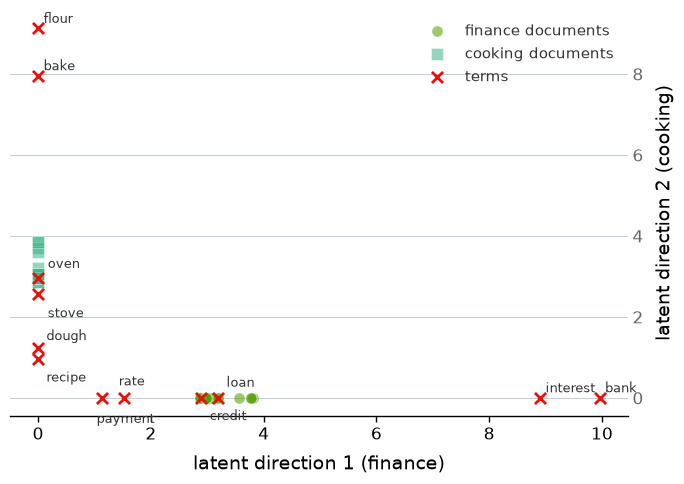

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, marker in [("finance", "o"), ("cooking", "s")]:
    idx = [i for i in range(len(docs)) if topic[i] == name]
    ax.scatter(doc_coords[idx, 0], doc_coords[idx, 1],
               marker=marker, alpha=0.55, label=f"{name} documents")
ax.scatter(term_coords[:, 0], term_coords[:, 1], marker="x", color=mt.RED,
           label="terms")
# synonym pairs coincide exactly, so their labels need staggered offsets
offsets = {"loan": (6, 8), "credit": (6, -16), "oven": (7, 7), "stove": (7, -17),
           "rate": (-4, 9), "payment": (-4, -18), "dough": (6, 6), "recipe": (6, -16)}
for j, term in enumerate(vocab):
    ax.annotate(term, term_coords[j], textcoords="offset points",
                xytext=offsets.get(term, (4, 4)), fontsize=9)
ax.set_xlabel("latent direction 1 (finance)")
ax.set_ylabel("latent direction 2 (cooking)")
ax.legend()
mt.apply_book_style(ax)
plt.tight_layout()
plt.show()

*Loan* and *credit* lie on the same ray from the origin, as do *oven* and *stove* — identical in direction, which is all cosine similarity measures, differing only in length (*loan*'s documents carry slightly more count mass). The factorization has recovered a small semantic fact from co-occurrence alone. The learned embeddings of Chapters 11–12 are this idea's descendants — words as vectors, similarity as an inner product — with the coordinates fit by maximum likelihood on a prediction task rather than extracted from counts by factorization.

**Explore.** Truncate at $k = 1$ and watch the two topics collapse onto one axis; add a third topic and check that $k = 3$ recovers it; replace the raw counts with tf-idf weights ($x_{ij} \cdot \log(m / \mathrm{df}_j)$, with $\mathrm{df}_j$ the number of documents containing term $j$) and see whether the hub words *bank* and *flour* lose their grip on the topic directions.